<a href="https://colab.research.google.com/github/siinwook/Deep-Learning-from-Scratch/blob/main/ch03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

step_functions

In [82]:
def step_functions(x):
  y=x>0
  return y.astype(int)

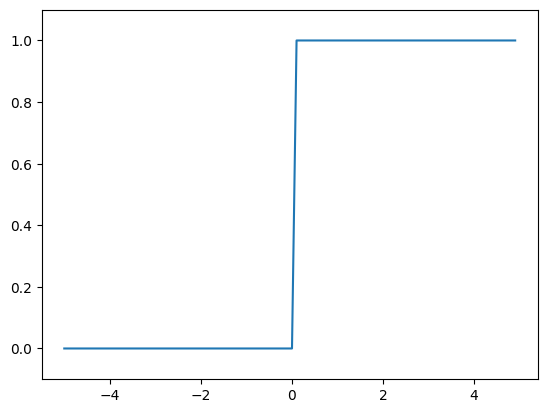

In [83]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(-5.0, 5.0, 0.1)
y = step_functions(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

sigmoid

In [84]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

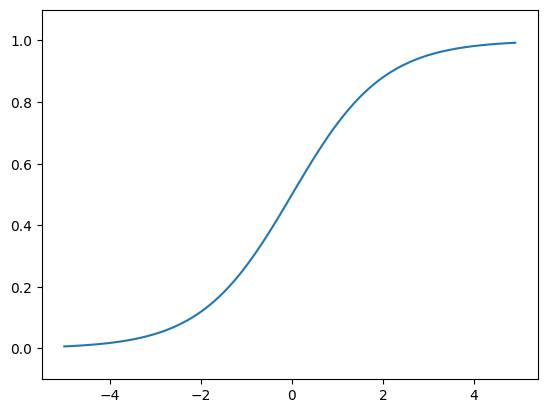

In [85]:
x = np.arange(-5.0,5.0,0.1)
y = sigmoid(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

ReLU

In [86]:
def relu(x):
  return np.maximum(0,x)

softmax

In [87]:
def softmax(a):
  c = np.max(a)
  exp_a = np.exp(a-c)
  return exp_a / np.sum(exp_a)

neural network mnist

(60000, 28, 28)


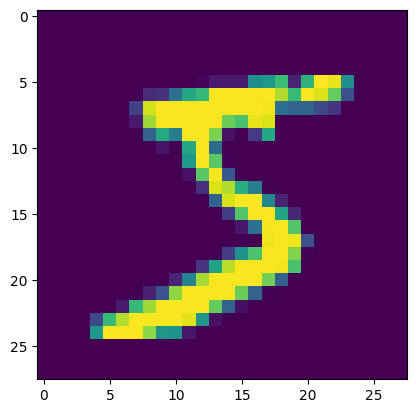

In [88]:
from keras.datasets import mnist
from matplotlib.pyplot import imshow

(x_train,t_train), (x_test,t_test) = mnist.load_data()
print(x_train.shape)

x_train,x_test = x_train/255.0, x_test/255.0
imshow(x_train[0].reshape(28,28))

neural network mnist (batch)

In [89]:
import pickle
from keras.datasets import mnist

def get_data():
  (x_train,t_train), (x_test,t_test) = mnist.load_data()
  x_test = x_test.reshape(10000,784)
  x_test = x_test/255.0
  return x_test,t_test

def init_network():
  with open("/content/sample_weight.pkl","rb") as f:
    network = pickle.load(f)
  return network

def predict(network, x): #(입력 - h1 - h2 - 출력) = (784 - 50 - 100 - 10)
  W1,W2,W3 = network['W1'],network['W2'],network['W3']
  b1,b2,b3 = network['b1'],network['b2'],network['b3']

  a1 = np.dot(x,W1) + b1
  z1 = sigmoid(a1)
  a2 = np.dot(z1,W2) + b2
  z2 = sigmoid(a2)
  a3 = np.dot(z2,W3) + b3
  y = softmax(a3)

  return y

x,t = get_data()
network = init_network()

accuracy_cnt = 0
for i in range(len(x)):
  y = predict(network,x[i])
  p = np.argmax(y)
  if p==t[i]:
    accuracy_cnt += 1
print("Accuracy:" + str(float(accuracy_cnt)/len(x)))

Accuracy:0.9352


In [90]:
import pickle
from keras.datasets import mnist

def get_data():
  (x_train,t_train), (x_test,t_test) = mnist.load_data()
  x_test = x_test.reshape(10000,784)
  x_test = x_test/255.0
  return x_test,t_test

def init_network():
  with open("/content/sample_weight.pkl","rb") as f:
    network = pickle.load(f)
  return network

def predict(network, x):
  W1,W2,W3 = network['W1'],network['W2'],network['W3']
  b1,b2,b3 = network['b1'],network['b2'],network['b3']

  a1 = np.dot(x,W1) + b1 # batch_size * 784 , 784 * 50
  z1 = sigmoid(a1)
  a2 = np.dot(z1,W2) + b2 # batch_size * 50, 50 * 100
  z2 = sigmoid(a2)
  a3 = np.dot(z2,W3) + b3 # batch_size * 100, 100 * 10
  y = softmax(a3)

  return y # batch_size * 10

x,t = get_data()
network = init_network()

batch_size = 100
accuracy_cnt = 0
for i in range(0,len(x),batch_size):
  x_batch = x[i:i+batch_size]
  y_batch = predict(network,x_batch)
  p = np.argmax(y_batch,axis=1) # batch_size * 10의 배열에서 1번 차원(10)의 각 원소에서 최댓값을 찾는다.
  accuracy_cnt += np.sum(p==t[i:i+batch_size])
print("Accuracy:" + str(float(accuracy_cnt)/len(x)))

Accuracy:0.9352
